In [8]:
import numpy as np
# import cupy as cp
import matplotlib.pyplot as plt
from typing import Optional, Type, Union
from scipy.interpolate import CubicSpline
import time

#few imports
from few.trajectory.inspiral import EMRIInspiral   #function to generate trajectories
from few.trajectory.ode.base import ODEBase        #superclass for defining modified flux trajectories
from few.trajectory.ode.flux import KerrEccEqFlux  #Adiabatic KerrEccEq base trajectory class

from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum
from few.utils.modeselector import ModeSelector
from few.utils.exceptions import TrajectoryOffGridException

from few.waveform import (
    FastSchwarzschildEccentricFlux, 
    SlowSchwarzschildEccentricFlux, 
    Pn5AAKWaveform,
    FastKerrEccentricEquatorialFlux,
    GenerateEMRIWaveform,
)

##### SuperKludge Imports #####
from few.trajectory.ode.flux import SuperKludgeFlux
from few.waveform.waveform import SuperKludgeWaveform #waveform module
###############################

from few.waveform.base import SphericalHarmonicWaveformBase #generic waveform generation class
from few.utils.baseclasses import SphericalHarmonic, KerrEccentricEquatorial, ParallelModuleBase, BackendLike

from few.utils.constants import YRSID_SI

from few.utils.utility import ( 
    get_mismatch, 
    get_m2_at_t, 
    get_p_at_t, 
    )

from few.utils.geodesic import (
    get_fundamental_frequencies,
    get_separatrix,
    get_kerr_geo_constants_of_motion,
    ELQ_to_pex,
    )

use_gpu = False


if not use_gpu:
    
    import few
    #tune few configuration
    cfg_set = few.get_config_setter(reset=True)
    
    cfg_set.enable_backends("cpu")
    cfg_set.set_log_level("info")
else:
    cfg_set.enable_backends("gpu")

    pass #let the backend decide for itself.

In [9]:
# define parameters
m1 = 1e6
m2 = 1e1
a = 0.9
e0 = 0.01
Y0 = 1.0
dist = 1.0
qS = np.pi/3
phiS = np.pi/4
qK = np.pi/5.
phiK = np.pi/6.
Phi_phi0 = 0.1
Phi_theta0 = 0.2
Phi_r0 = 0.3
dt = 10.0
T = 1.0
chi2 = 0.6

dev_0_p=0.0
dev_0_e=0.0
dev_1_p=0.0
dev_1_e=0.0
dev_2_p=0.0
dev_2_e=0.0

#initializing trajectories
start = time.time()


SK_traj = EMRIInspiral(func=SuperKludgeFlux)
print(time.time() - start)

evolve_1PA = True
evolve_primary = False
evolve_2PA = False
deviation_included=True
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

#get_p_at_t may fail with SuperKludge, especially with lower eccentricities, so we use KerrEccEq to generate p0 
p0 = get_p_at_t(traj_module=SK_traj, t_out=T, traj_args=[m1, m2, a, e0, Y0, *add_args]) + 0.1 #near plunge EMRI
print('p0: ', p0)

1.390570878982544
p0:  7.26410070944802


In [10]:
#sparse trajectories prone to spline errors, denser trajectories give a more accurate picture of dephasings.

max_step_days = 1.0 #max trajectory step size in days. Smaller value leads to more stable trajectories, but takes longer to compute. Likely needs fiddling.
max_step_size = max_step_days*24*60*60 #in seconds
inspiral_kwargs = {
    "err":1e-11, #error tolerance in the DOPR integration routine. Default = 1e-11
    "max_step_size":max_step_size, #in seconds
}

In [11]:
p0=10.5
start = time.time()
evolve_1PA = False
evolve_primary = False
evolve_2PA = False
deviation_included=True
dev_0_p=0.1
dev_0_e=0.1

add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
t1, p1, e1, x1, pp1, pt1, pr1, _, _ = SK_traj(m1, m2, a, p0, e0, Y0, *add_args, Phi_phi0=Phi_phi0, Phi_theta0=Phi_theta0, Phi_r0=Phi_r0, T=0.5, dt=dt,max_step_size=max_step_size)
print(time.time() - start)

start = time.time()
evolve_1PA = False
evolve_primary = False
evolve_2PA = False
deviation_included=True

dev_0_p=0.4
dev_0_e=0.4

add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
t2, p2, e2, x2, pp2, pt2, pr2, _, _ = SK_traj(m1, m2, a, p0, e0, Y0, *add_args, Phi_phi0=Phi_phi0, Phi_theta0=Phi_theta0, Phi_r0=Phi_r0, T=0.5, dt=dt, max_step_size=max_step_size)
print(time.time() - start)

0.41060805320739746
0.3969700336456299


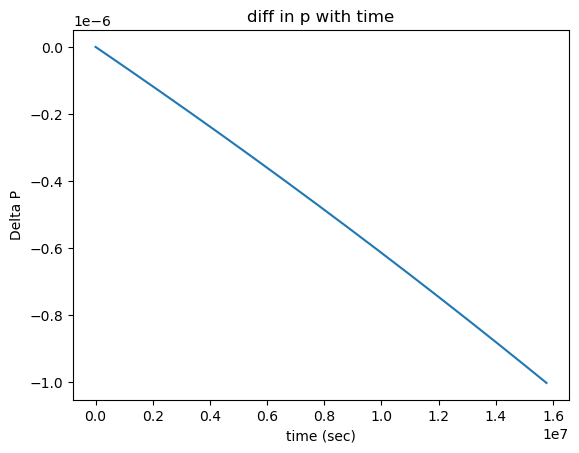

In [12]:
t = np.linspace(max(t1[0],t2[0]),min(t2[-2],t1[-2]),1000)
p1 = CubicSpline(t1,p1)(t)
p2 = CubicSpline(t2,p2)(t)

plt.plot(t,p2-p1)
plt.xlabel('time (sec)')
plt.ylabel('Delta P')
plt.title("diff in p with time")
plt.show()

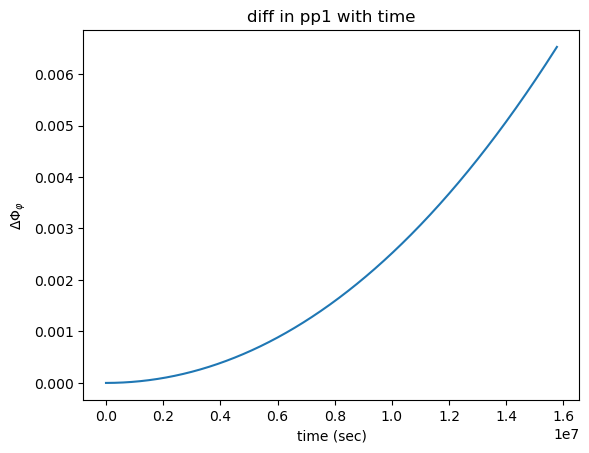

In [13]:
t = np.linspace(max(t1[0],t2[0]),min(t2[-2],t1[-2]),1000)
pp1 = CubicSpline(t1,pp1)(t)
pp2 = CubicSpline(t2,pp2)(t)

plt.plot(t,pp2-pp1)
plt.xlabel('time (sec)')
plt.ylabel(r'$\Delta\Phi_{\varphi}$')
plt.title("diff in pp1 with time")

plt.show()

In [14]:
p0=10.5
start = time.time()
evolve_1PA = False
evolve_primary = False
evolve_2PA = False
deviation_included=True
dev_0_p=0.1
dev_0_e=0.1
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
t1, p1, e1, x1, pp1, pt1, pr1, _, _ = SK_traj(m1, m2, a, p0, e0, Y0, *add_args, Phi_phi0=Phi_phi0, Phi_theta0=Phi_theta0, Phi_r0=Phi_r0, T=0.5, dt=dt,max_step_size=max_step_size)
print(time.time() - start)

start = time.time()
evolve_1PA = False
evolve_primary = False
evolve_2PA = False
deviation_included=True

dev_0_p=-0.4
dev_0_e=-0.4
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
t2, p2, e2, x2, pp2, pt2, pr2, _, _ = SK_traj(m1, m2, a, p0, e0, Y0, *add_args, Phi_phi0=Phi_phi0, Phi_theta0=Phi_theta0, Phi_r0=Phi_r0, T=0.5, dt=dt, max_step_size=max_step_size)
print(time.time() - start)

0.42419910430908203
0.40080976486206055


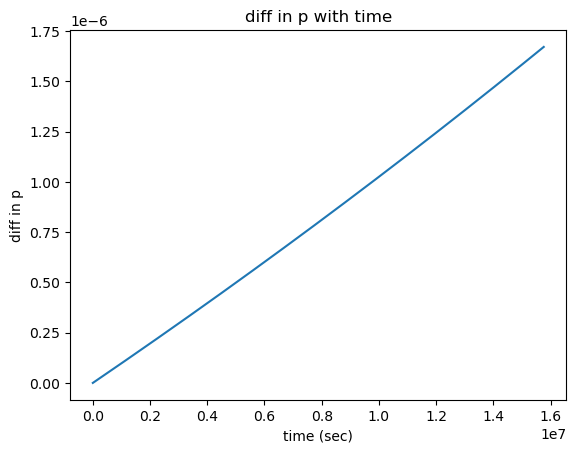

In [15]:
t = np.linspace(max(t1[0],t2[0]),min(t2[-2],t1[-2]),1000)
p1 = CubicSpline(t1,p1)(t)
p2 = CubicSpline(t2,p2)(t)

plt.plot(t,p2-p1)
plt.xlabel('time (sec)')
plt.ylabel('diff in p')
plt.title("diff in p with time")

plt.show()

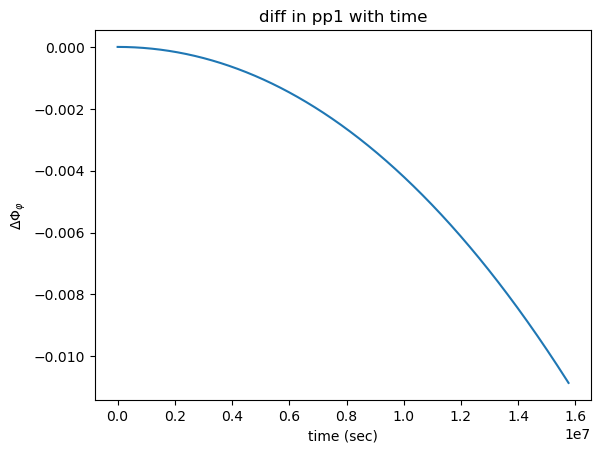

In [16]:

t = np.linspace(max(t1[0],t2[0]),min(t2[-2],t1[-2]),1000)
pp1 = CubicSpline(t1,pp1)(t)
pp2 = CubicSpline(t2,pp2)(t)

plt.plot(t,pp2-pp1)
plt.xlabel('time (sec)')
plt.ylabel(r'$\Delta\Phi_{\varphi}$')
plt.title("diff in pp1 with time")

plt.show()

In [17]:
#waveform setup
use_gpu=False
sum_kwargs = {
            "pad_output": True}
start = time.time()
superkludge_wave = GenerateEMRIWaveform(SuperKludgeWaveform,\
                                    sum_kwargs=sum_kwargs,\
                                    return_list=True
                                    ,use_gpu=False)
print(time.time()-start)
superkludge_wave

5.250308990478516


In [18]:
evolve_1PA = False
evolve_primary = False
evolve_2PA = False
start = time.time()
deviation_included=True
dev_0_p=0.4
dev_0_e=0.1
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
waveform_1 = superkludge_wave(m1, m2, a, p0, e0, Y0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, *add_args, dt=dt, T=T)
deviation_included=True
dev_0_p=-0.4
dev_0_e=-0.1
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
waveform_2 = superkludge_wave(m1, m2, a, p0, e0, Y0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, *add_args, dt=dt, T=T)
print('average time: ', (time.time()-start)/2)

average time:  2.8862935304641724


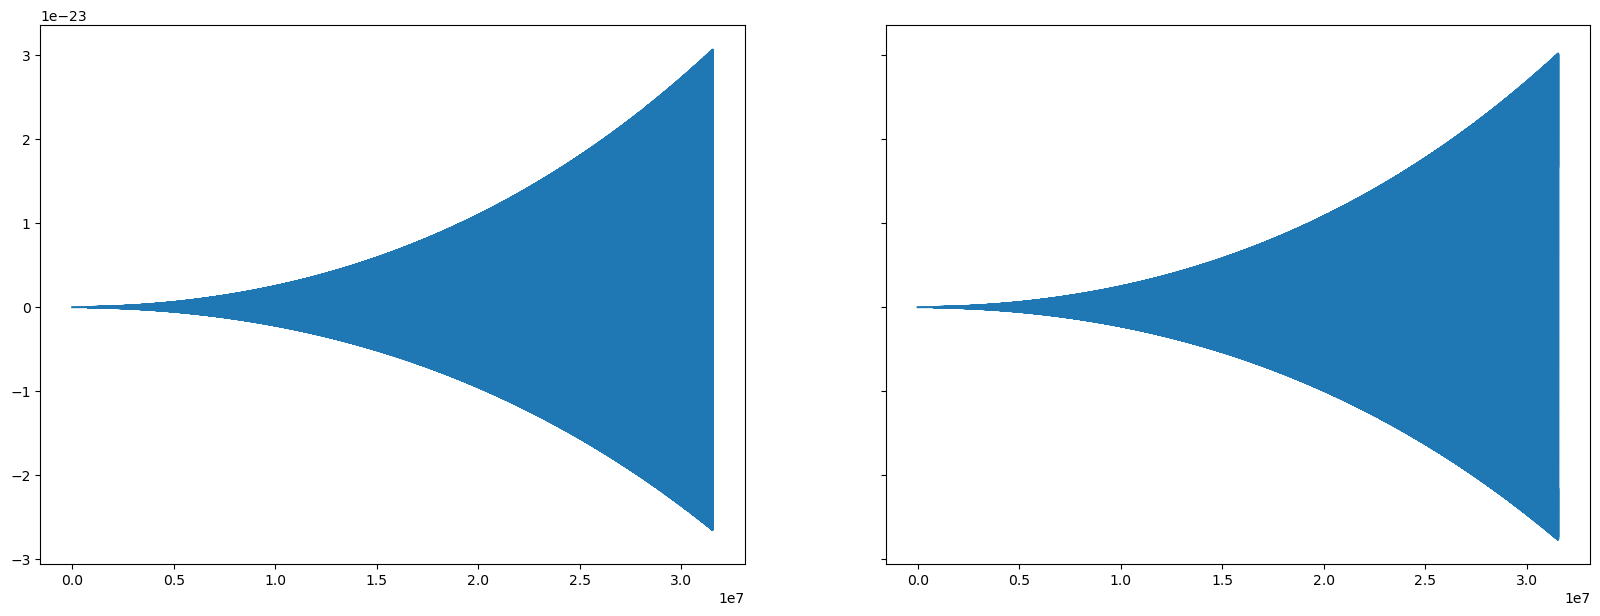

In [19]:
time_steps = np.linspace(0.0,T*YRSID_SI,len(waveform_1[0]))

fig, axs = plt.subplots(1,2,figsize=(20,7),sharey=True)

# axs[0].plot(time_steps[95000:100000],waveform_1[0][95000:100000])
# axs[0].plot(time_steps[95000:100000],waveform_2[0][95000:100000])
axs[0].plot(time_steps,waveform_1[1]-waveform_2[1])

axs[1].plot(time_steps,waveform_1[0]-waveform_2[0])
# axs[1].plot(time_steps[-10000:],waveform_1[1][-10000:])
# axs[1].plot(time_steps[-10000:],waveform_2[1][-10000:])

plt.show()

In [20]:
evolve_1PA = True
evolve_primary = False
evolve_2PA = False
start = time.time()
deviation_included=False
dev_0_p=0.1
dev_0_e=0.1
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
waveform_1 = superkludge_wave(m1, m2, a, p0, e0, Y0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, *add_args, dt=dt, T=T)
deviation_included=True
#around this value a very little deviationß
dev_0_p=-0.05
dev_0_e=-0.05
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
waveform_2 = superkludge_wave(m1, m2, a, p0, e0, Y0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, *add_args, dt=dt, T=T)
print('average time: ', (time.time()-start)/2)

average time:  0.4633779525756836


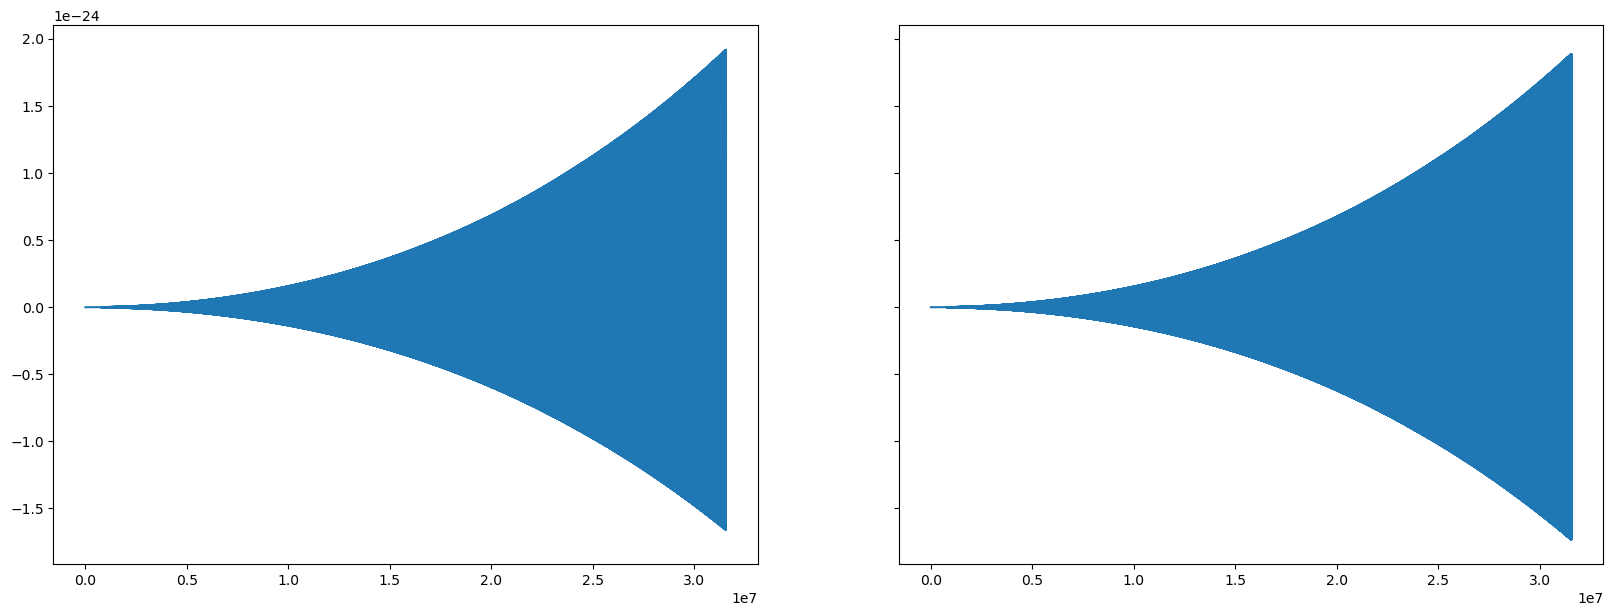

In [21]:
time_steps = np.linspace(0.0,T*YRSID_SI,len(waveform_1[0]))

fig, axs = plt.subplots(1,2,figsize=(20,7),sharey=True)

# axs[0].plot(time_steps[95000:100000],waveform_1[0][95000:100000])
# axs[0].plot(time_steps[95000:100000],waveform_2[0][95000:100000])
axs[0].plot(time_steps,waveform_1[1]-waveform_2[1])

axs[1].plot(time_steps,waveform_1[0]-waveform_2[0])
# axs[1].plot(time_steps[-10000:],waveform_1[1][-10000:])
# axs[1].plot(time_steps[-10000:],waveform_2[1][-10000:])

plt.show()

In [22]:
p=np.fft.fftshift(np.fft.fft(waveform_1)) * 10
p[0]

array([2.25116530e-22+8.09038560e-29j, 2.25116545e-22+2.98666827e-28j,
       2.25116561e-22+5.23112837e-28j, ...,
       2.25116561e-22-5.23112613e-28j, 2.25116545e-22-2.98666758e-28j,
       2.25116530e-22-8.09041773e-29j], shape=(3155815,))

In [23]:
m1 = 1e6
m2 = 1e1
a = 0.
p0 = 9.5
e0 = 0.4
xI0 = 1.0
dist = 1
qS = 0.5
phiS = 1
qK = 1 #fixed
phiK = phiS + np.pi/3#FIXED
Phi_phi0 = 0.4#FIXED
Phi_theta0 =0.2
Phi_r0 = 0.5

dt = 10.0
T = 0.5

chi2 = 0.8

dev_0_p=0.0
dev_0_e=0.0
dev_1_p=0.0
dev_1_e=0.0
dev_2_p=0.0
dev_2_e=0.0
evolve_1PA = False
evolve_primary = False
evolve_2PA = False
deviation_included=False
p0=9.0

add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

waveform = superkludge_wave(m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, *add_args, dt=dt, T=T)


In [26]:
np.savetxt("../../Results/first_sampling_data.txt",waveform)

In [27]:
truth=np.asarray([6,1,9.0,.4,1.0,0.5,1.0,0.4,0.5,0.8])
np.savetxt("../../Results/truth_first_sampling_data.txt",truth)